[2026-08-02 13:53:34] [info     ] calculating_e2e_factor         end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
        date instrument    factor
0 2024-01-02  000006.SZ  0.003715
1 2024-01-02  000011.SZ -0.005697
2 2024-01-02  000012.SZ  0.010917
3 2024-01-02  000016.SZ -0.028543
4 2024-01-02  000019.SZ  0.007860
[2026-08-02 13:54:21] [info     ] evaluating_e2e_factor
[2026-08-02 13:54:21] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-02 13:54:21] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-02 13:54:21] [info     ] 未提供因子池，只进行单因子分析
[2026-08-02 13:54:21] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-02 13:54:22] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-02 13:54:22] [info     ] ========== 数据检查 ==========
[2026-08-02 13:54:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor']
[2026-08-02 13:54:22] [info     ] 通过：唯一性检查
[2026-08-02 13:54:22] [info     ] 通过：

时段,IC
2024-01-15~2024-02-08,0.0193
2024-09-24~2024-10-08,0.0440

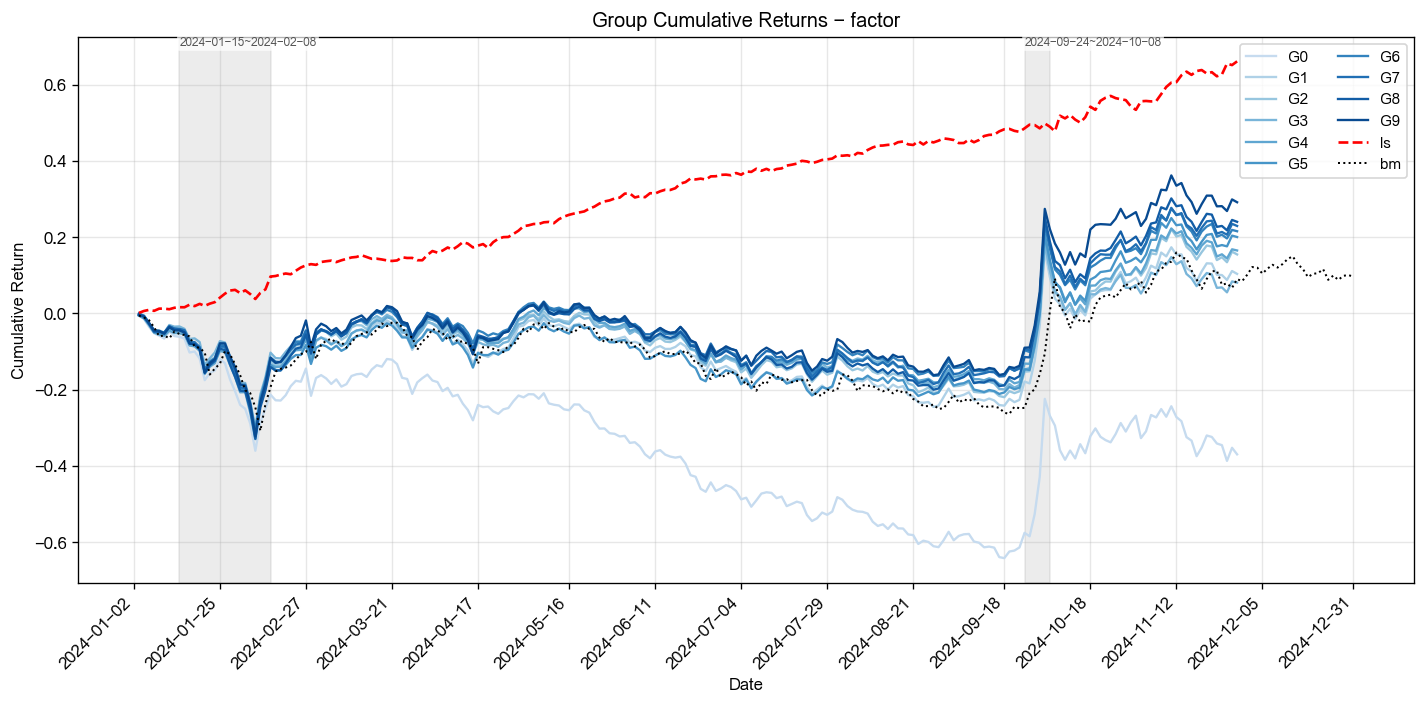
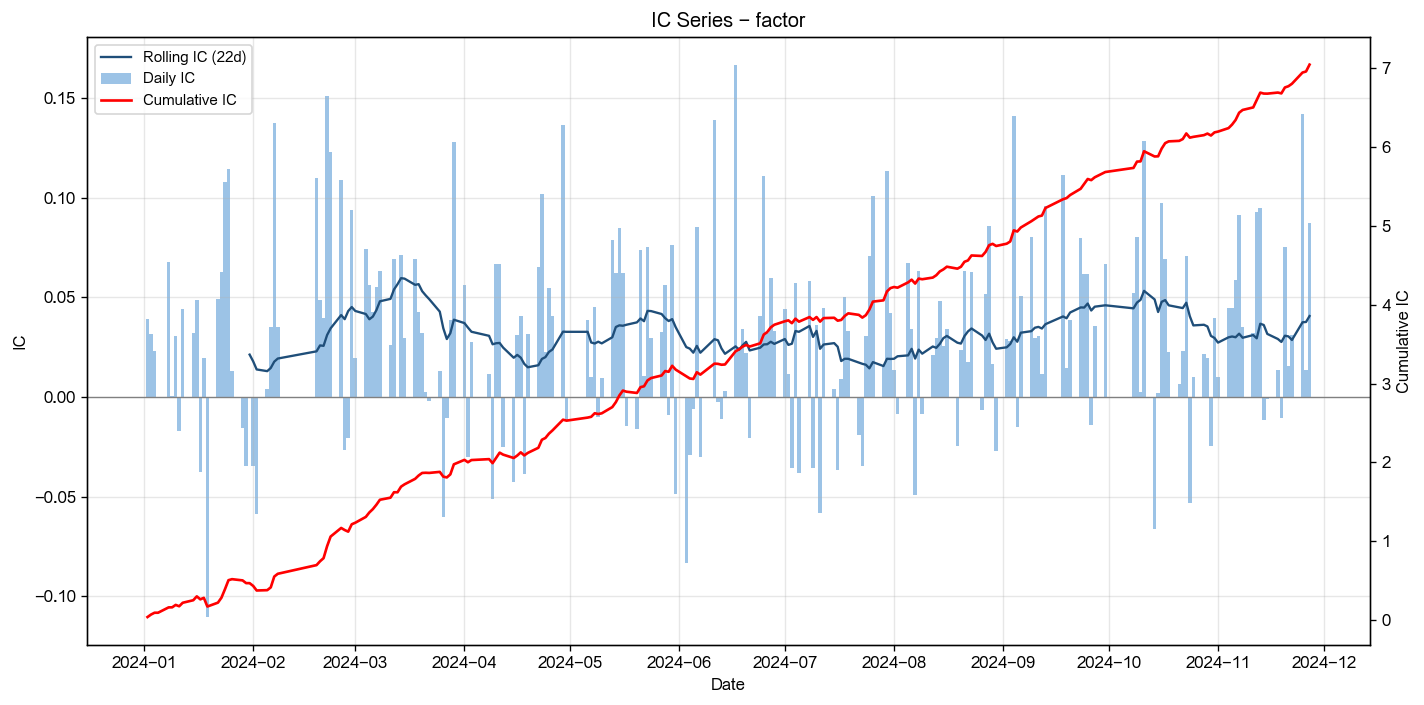
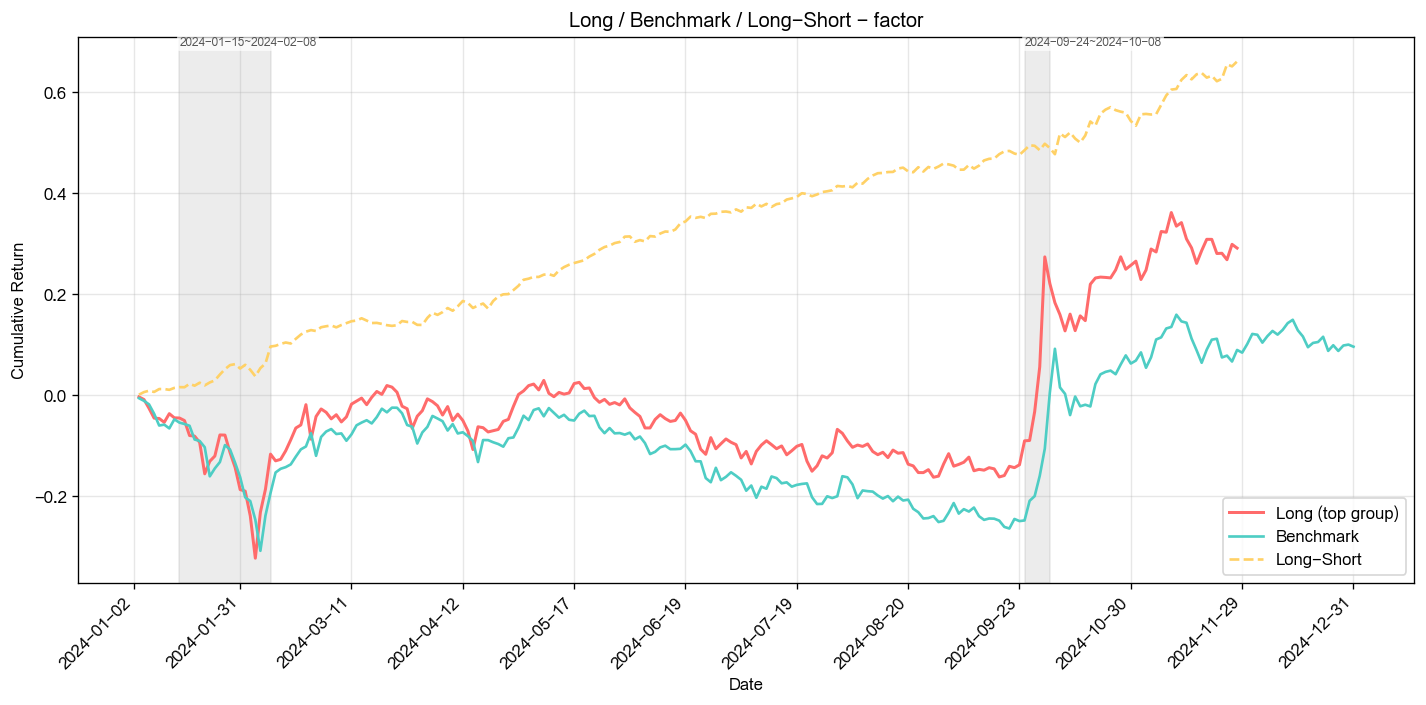
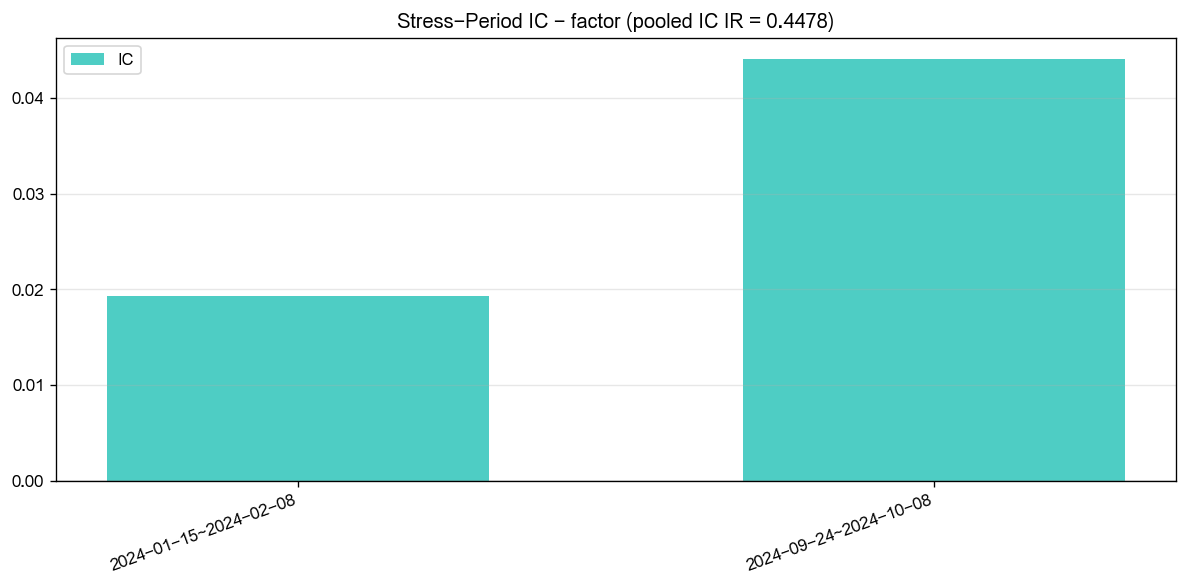
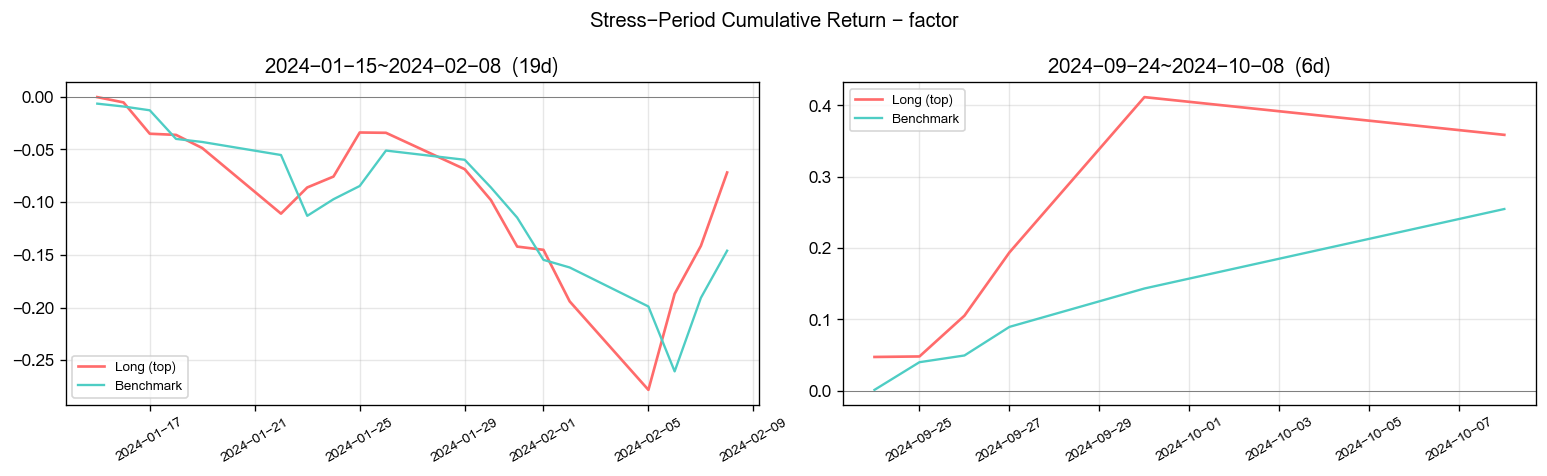

[2026-08-02 13:55:34] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-02 13:55:34] [warning  ] 返回的Outputs实例(size=51770507) 大于 64K, 将不会被缓存
[2026-08-02 13:55:34] [info     ] bigalpha_eval.v4 运行完成 [73.157s].


In [1]:
"""Prediction-only 61-day structured E2E submission trained on 2019--2024."""

import base64
import json
import zlib
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F


BOOK_LEVELS = (1, 2, 3)
OHLC_COLS = ("open", "high", "low", "close")
PRICE_COLS = (*OHLC_COLS, *(f"ask_price{i}" for i in BOOK_LEVELS), *(f"bid_price{i}" for i in BOOK_LEVELS))
SIZE_COLS = (
    "deal_number", "volume", "amount", *(f"ask_volume{i}" for i in BOOK_LEVELS),
    *(f"bid_volume{i}" for i in BOOK_LEVELS), *(f"ask_num_orders{i}" for i in BOOK_LEVELS),
    *(f"bid_num_orders{i}" for i in BOOK_LEVELS),
)
RAW_INPUT_COLS = ("adjust_factor", *PRICE_COLS, *SIZE_COLS)
WINDOW_BARS = 488
QUERY_BUFFER_DAYS = 120
MODEL_FILENAME = "e2e_regime_fama_full.json"


@dataclass(frozen=True)
class FamaE2EConfig:
    n_features: int = len(RAW_INPUT_COLS)
    history_bars: int = 488
    bars_per_day: int = 8
    long_days: int = 61
    short_bars: int = 84
    two_hour_bars: int = 4
    short_2h_bars: int = 21
    channels: int = 48
    hidden: int = 64
    long_channels: int = 24
    comparison_hidden: int = 32
    context_factors: int = 6
    local_attention_2h_bars: int = 10
    local_attention_heads: int = 4
    use_local_attention: bool = True
    use_daily_context_attention: bool = False
    dropout: float = 0.10


class TwoHourEncoder(nn.Module):
    def __init__(self, n_features, channels, bars_per_state):
        super().__init__()
        self.bars_per_state = bars_per_state
        self.bar_proj = nn.Sequential(nn.LayerNorm(n_features), nn.Linear(n_features, channels), nn.GELU())
        self.filter = nn.Conv1d(channels, channels, bars_per_state, groups=channels)
        self.mix = nn.Sequential(nn.LayerNorm(channels), nn.Linear(channels, channels), nn.GELU())

    def forward(self, x):
        if x.ndim != 3 or x.shape[1] != self.bars_per_state:
            raise ValueError(f"expected [batch, {self.bars_per_state}, fields], got {tuple(x.shape)}")
        return self.mix(self.filter(self.bar_proj(x).transpose(1, 2)).squeeze(-1))


class SequenceEncoder(nn.Module):
    def __init__(self, channels, window_2h):
        super().__init__()
        self.window_2h = window_2h
        self.filter = nn.Conv1d(channels, channels, window_2h, groups=channels)
        self.mix = nn.Sequential(nn.LayerNorm(channels), nn.Linear(channels, channels), nn.GELU())

    def forward(self, x):
        if x.ndim != 3 or x.shape[1] != self.window_2h:
            raise ValueError(f"expected [batch, {self.window_2h}, channels], got {tuple(x.shape)}")
        return self.mix(self.filter(x.transpose(1, 2)).squeeze(-1))


class Comparator(nn.Module):
    def __init__(self, channels, hidden, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(channels * 4), nn.Linear(channels * 4, hidden), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(hidden, 1),
        )

    def forward(self, current, reference):
        joint = torch.cat((current, reference, current - reference, current * reference), dim=1)
        return self.net(joint).squeeze(-1)


class StructuredSignalLayer(nn.Module):
    def forward(self, route, near, states):
        up, above = torch.sigmoid(route), torch.sigmoid(near)
        down, below = 1.0 - up, 1.0 - above
        up_above, up_below = up * above, up * below
        down_above, down_below = down * above, down * below
        dev = states["deviation"]
        return torch.stack((
            torch.tanh(route), up * states["ma10_gap"], up * F.relu(dev), up * F.relu(-dev),
            up_above * states["instability"], up_above * states["high_close"],
            up_above * F.relu(-states["volume_gap"]), up_below * F.relu(-states["volume_gap"]),
            down_below * states["low_close"], down * F.relu(-states["rsi_like"]),
            down_above * F.relu(-states["m10"]), up_above * states["imbalance"],
            down_below * F.relu(-states["imbalance"]), down_above * states["imbalance"],
            up_above * states["volatility"], up_below * states["volatility"], down_below * states["volatility"],
        ), dim=1)


class PathTransformerEncoder(nn.Module):
    def __init__(self, channels, heads, feedforward, dropout, max_bars=20):
        super().__init__()
        self.max_bars = max_bars
        self.lag_position = nn.Parameter(torch.zeros(1, max_bars, channels))
        layer = nn.TransformerEncoderLayer(d_model=channels, nhead=heads, dim_feedforward=feedforward,
                                           dropout=dropout, activation="gelu", batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=1, enable_nested_tensor=False)
        self.output_norm = nn.LayerNorm(channels)

    def forward(self, states):
        positions = self.lag_position[:, self.max_bars - states.shape[1]:]
        return self.output_norm(self.encoder(states + positions)[:, -1])


class DailyRawEncoder(nn.Module):
    def __init__(self, n_features, channels, bars_per_day):
        super().__init__()
        self.bars_per_day = bars_per_day
        self.bar_proj = nn.Sequential(nn.LayerNorm(n_features), nn.Linear(n_features, channels), nn.GELU())
        self.filter = nn.Conv1d(channels, channels, bars_per_day, groups=channels)
        self.mix = nn.Sequential(nn.LayerNorm(channels), nn.Linear(channels, channels), nn.GELU())

    def forward(self, x):
        if x.ndim != 3 or x.shape[1] != self.bars_per_day:
            raise ValueError(f"expected [batch, {self.bars_per_day}, fields], got {tuple(x.shape)}")
        return self.mix(self.filter(self.bar_proj(x).transpose(1, 2)).squeeze(-1))


class FamaStructuredRegimeE2E(nn.Module):
    def __init__(self, cfg=FamaE2EConfig()):
        super().__init__()
        self.cfg = cfg
        c, h, d = cfg.channels, cfg.hidden, cfg.dropout
        self.two_hour_enc = TwoHourEncoder(cfg.n_features, c, cfg.two_hour_bars)
        self.trend_enc = SequenceEncoder(c, 20)
        self.ma5_enc = SequenceEncoder(c, 5)
        self.ma10_enc = SequenceEncoder(c, 10)
        self.volume_enc = SequenceEncoder(c, 20)
        self.momentum_enc = SequenceEncoder(c, 11)
        self.path_transformer = PathTransformerEncoder(c, heads=4, feedforward=96, dropout=d)
        self.trend_attention_scale = nn.Parameter(torch.tensor(0.10))
        self.momentum_attention_scale = nn.Parameter(torch.tensor(0.10))
        self.trend_head = nn.Linear(c, 3)
        self.ma5_gate = Comparator(c, h, d)
        self.ma10_head = Comparator(c, h, d)
        self.volume_head = Comparator(c, h, d)
        self.momentum_head = nn.Linear(c, 2)
        self.current_head = nn.Linear(c, 4)
        self.signal_layer = StructuredSignalLayer()
        self.factor_head = nn.Linear(17, 1)

        price_ids = [RAW_INPUT_COLS.index(name) for name in ("open", "high", "low", "close")]
        activity_ids = [RAW_INPUT_COLS.index(name) for name in ("deal_number", "volume", "amount")]
        self.register_buffer("price_indices", torch.tensor(price_ids, dtype=torch.long), persistent=False)
        self.register_buffer("activity_indices", torch.tensor(activity_ids, dtype=torch.long), persistent=False)
        self.price_daily = DailyRawEncoder(4, cfg.long_channels, 8)
        self.activity_daily = DailyRawEncoder(3, cfg.long_channels, 8)
        self.price_30_ref, self.price_60_ref = SequenceEncoder(cfg.long_channels, 30), SequenceEncoder(cfg.long_channels, cfg.long_days - 1)
        self.activity_30_ref, self.activity_60_ref = SequenceEncoder(cfg.long_channels, 30), SequenceEncoder(cfg.long_channels, cfg.long_days - 1)
        self.price_compare = Comparator(cfg.long_channels, cfg.comparison_hidden, d)
        self.activity_compare = Comparator(cfg.long_channels, cfg.comparison_hidden, d)
        self.context_factor_head = nn.Sequential(nn.LayerNorm(4), nn.Linear(4, cfg.context_factors), nn.Tanh())
        self.context_modulator = nn.Linear(cfg.context_factors, 19)

    def _short_states(self, raw):
        batch = len(raw)
        h2 = self.two_hour_enc(raw.reshape(batch, 21, 4, -1).reshape(-1, 4, self.cfg.n_features)).reshape(batch, 21, -1)
        current = h2[:, -1]
        trend_states, momentum_states = h2[:, -20:], h2[:, -11:]
        trend = self.trend_enc(trend_states) + self.trend_attention_scale * self.path_transformer(trend_states)
        near_ref = self.ma5_enc(h2[:, -6:-1])
        mid_ref = self.ma10_enc(h2[:, -10:])
        activity_ref = self.volume_enc(h2[:, :-1])
        momentum_ref = self.momentum_enc(momentum_states) + self.momentum_attention_scale * self.path_transformer(momentum_states)
        route, dev, inst_raw = self.trend_head(trend).unbind(1)
        stren, m_mid = self.momentum_head(momentum_ref).unbind(1)
        high_raw, low_raw, book_raw, variation_raw = self.current_head(current).unbind(1)
        states = {
            "ma10_gap": torch.tanh(self.ma10_head(current, mid_ref)), "deviation": dev,
            "instability": F.softplus(inst_raw), "volume_gap": self.volume_head(current, activity_ref),
            "rsi_like": stren, "m10": m_mid, "high_close": torch.sigmoid(high_raw),
            "low_close": torch.sigmoid(low_raw), "imbalance": torch.tanh(book_raw),
            "volatility": F.softplus(variation_raw),
        }
        return route, self.ma5_gate(current, near_ref), states

    def _regime_controls(self, raw):
        batch = len(raw)
        price = self.price_daily(raw[..., self.price_indices].reshape(batch, self.cfg.long_days, 8, 4).reshape(-1, 8, 4)).reshape(batch, self.cfg.long_days, -1)
        activity = self.activity_daily(raw[..., self.activity_indices].reshape(batch, self.cfg.long_days, 8, 3).reshape(-1, 8, 3)).reshape(batch, self.cfg.long_days, -1)
        price_now, activity_now = price[:, -1], activity[:, -1]
        summaries = torch.stack((
            self.price_compare(price_now, self.price_30_ref(price[:, -31:-1])),
            self.price_compare(price_now, self.price_60_ref(price[:, :-1])),
            self.activity_compare(activity_now, self.activity_30_ref(activity[:, -31:-1])),
            self.activity_compare(activity_now, self.activity_60_ref(activity[:, :-1])),
        ), dim=1)
        return self.context_modulator(self.context_factor_head(summaries))

    def forward(self, x):
        if x.ndim != 3 or x.shape[-1] != self.cfg.n_features or x.shape[1] < WINDOW_BARS:
            raise ValueError(f"expected [batch, >= {WINDOW_BARS}, {self.cfg.n_features}], got {tuple(x.shape)}")
        raw = x[:, -WINDOW_BARS:]
        control = self._regime_controls(raw)
        route, near, states = self._short_states(raw[:, -84:])
        route = route + 0.5 * torch.tanh(control[:, 0])
        near = near + 0.5 * torch.tanh(control[:, 1])
        signals = self.signal_layer(route, near, states)
        base_weights = self.factor_head.weight.squeeze(0)
        weights = base_weights + 0.20 * torch.tanh(control[:, 2:])
        return self.factor_head.bias.squeeze(0) + (signals * weights).sum(dim=1)


def _canonicalize(raw, stats):
    frame = raw[["date", "instrument", *RAW_INPUT_COLS]].copy()
    frame["date"] = pd.to_datetime(frame["date"])
    for col in RAW_INPUT_COLS:
        frame[col] = pd.to_numeric(frame[col], errors="coerce").astype("float32")
    if stats["adjust_prices"]:
        multiplier = frame["adjust_factor"].where(frame["adjust_factor"] > 0, np.nan)
        for col in PRICE_COLS:
            frame[col] = frame[col] * multiplier
    frame.loc[:, list(PRICE_COLS)] = frame.loc[:, list(PRICE_COLS)].where(frame.loc[:, list(PRICE_COLS)] > 0, np.nan)
    frame = frame.sort_values(["instrument", "date"], kind="stable")
    frame.loc[:, list(PRICE_COLS)] = frame.groupby("instrument", sort=False)[list(PRICE_COLS)].ffill()
    for col in stats["log1p_cols"]:
        values = frame[col].to_numpy(dtype=np.float32, copy=True)
        valid = np.isfinite(values)
        values[valid] = np.log1p(np.maximum(values[valid], 0.0))
        frame[col] = values
    values = frame[list(stats["feature_cols"])].to_numpy(dtype=np.float32, copy=True)
    values = np.where(np.isfinite(values), values, np.asarray(stats["fill_values"], dtype=np.float32))
    frame.loc[:, list(stats["feature_cols"])] = (values - np.asarray(stats["means"], dtype=np.float32)) / np.asarray(stats["stds"], dtype=np.float32)
    return frame.sort_values(["instrument", "date"], kind="stable")


def _load_model(model_path):
    checkpoint = json.loads(Path(model_path).read_text(encoding="utf-8"))
    model = FamaStructuredRegimeE2E(FamaE2EConfig(**checkpoint["model_config"]))
    weights = {}
    for name, item in checkpoint["state_dict"].items():
        data = zlib.decompress(base64.b64decode(item["data_b64"]))
        weights[name] = torch.from_numpy(np.frombuffer(data, dtype=np.dtype(item["dtype"])).copy().reshape(item["shape"]))
    model.load_state_dict(weights)
    return model, checkpoint["preprocess"]


@torch.inference_mode()
def _predict(model, canonical, start_date, end_date, device):
    output = []
    model.eval()
    for instrument, stock in canonical.groupby("instrument", sort=False):
        fields = stock[list(RAW_INPUT_COLS)].to_numpy(dtype=np.float32, copy=False)
        dates = stock["date"].to_numpy(dtype="datetime64[ns]")
        days = dates.astype("datetime64[D]")
        eod = np.flatnonzero(np.r_[days[1:] != days[:-1], True])
        use = [i for i in eod if i >= WINDOW_BARS - 1 and start_date <= pd.Timestamp(days[i]) <= end_date]
        if not use:
            continue
        windows = np.stack([fields[i - WINDOW_BARS + 1:i + 1] for i in use])
        batches = np.array_split(windows, max(1, int(np.ceil(len(windows) / 256))))
        factor = np.concatenate([model(torch.from_numpy(batch).to(device)).cpu().numpy() for batch in batches])
        output.append(pd.DataFrame({"date": pd.to_datetime(days[use]), "instrument": instrument, "factor": factor.astype("float64")}))
    return pd.concat(output, ignore_index=True) if output else pd.DataFrame(columns=["date", "instrument", "factor"])


def main(datasources, start_date, end_date, model_path=MODEL_FILENAME):
    """Return exactly date, instrument, factor from cloud 30m raw bars."""
    import dai

    start, end = pd.Timestamp(start_date).normalize(), pd.Timestamp(end_date).normalize()
    # The 61-day model uses the platform-provided quarterly warmup only.
    history_start = (start - pd.Timedelta(days=QUERY_BUFFER_DAYS)).strftime("%Y-%m-%d 00:00:00")
    table = datasources.get("bar30m") or datasources.get("bar_30m") or next(iter(datasources.values()))
    sql = f"SELECT date, instrument, {', '.join(RAW_INPUT_COLS)} FROM {table} ORDER BY instrument, date"
    raw = dai.query(sql, filters={"date": [history_start, str(end_date)]}).df()
    if raw.empty:
        return pd.DataFrame(columns=["date", "instrument", "factor"])
    model, stats = _load_model(Path(model_path))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    result = _predict(model.to(device), _canonicalize(raw, stats), start, end, device)
    if result.empty or not np.isfinite(result["factor"]).all():
        raise ValueError("No finite E2E factor values were generated.")
    return result[["date", "instrument", "factor"]].sort_values(["date", "instrument"]).reset_index(drop=True)


if __name__ == "__main__":
    from bigmodule import M
    import structlog

    logger = structlog.get_logger()
    datasources = {"bar30m": "bigalpha_2026_stock_bar30m"}
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("calculating_e2e_factor", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())
    logger.info("evaluating_e2e_factor")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
